In [ ]:
pip install asammdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.7/328.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.8/260.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.3 which is incompatible.
langchain 0.3.19 requires numpy<2,>=1.26.4; python_version < "3.12", but you have numpy 2.2.3 which is incompati

**Les fonctions de scipy.signal sont également actuellement inutilisables au moment de la fin du projet. Il faut repasser sur un environnement type Jupyter notebook pour pouvoir exécuter les codes normalement**

In [ ]:
import os
import numpy as np
#from scipy.signal import welch, butter, sosfiltfilt, freqs

import matplotlib.pyplot as plt
#from scipy.io.wavfile import write
#from scipy.signal import periodogram, spectrogram, oaconvolve
from asammdf import MDF

import librosa

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
os.chdir('/content/drive/My Drive/OneDrive-Bibliothèquespartagées-SNCF/TLI - Données SIM GrpO365 - Huddersfield - Campagne de mesure juin 2024')

l_path= [
         "RecordFile_24-06-26_16_35_56_492.mf4", # 40 km/h
         "RecordFile_24-06-26_16_43_59_644.mf4", # 80 km/h
         "RecordFile_24-06-26_17_02_13_620.mf4", # 120 km/h
         "RecordFile_24-06-26_17_08_57_704.mf4", # 160 km/h
         "RecordFile_24-06-25_09_38_22_758.mf4",
         ]

path = l_path[0] # Selection of the data to read
name = path.split('.')[0]

data = MDF(path, memory='low')

print(data.info())

{'version': '4.11', 'program': 'Sefram_D', 'comment': '<HDcomment>\n <TX/>\n <common_properties>\n  <e name="author"/>\n  <e name="department"/>\n  <e name="project"/>\n  <e name="subject"/>\n  <e name="timezone">Europe/Paris</e>\n </common_properties>\n <time_source>internal clock</time_source>\n</HDcomment>', 'groups': 1, 'group 0': {'cycles': 20279056, 'comment': 'Channel group for Freq (freq 100000)', 'channels count': 14, 'channel 0': 'name="Time" type=VIRTUAL MASTER', 'channel 1': 'name="3A_X" type=VALUE', 'channel 2': 'name="Harold" type=VALUE', 'channel 3': 'name="Son_4" type=VALUE', 'channel 4': 'name="3A_Y" type=VALUE', 'channel 5': 'name="3A_Z" type=VALUE', 'channel 6': 'name="Acc_1" type=VALUE', 'channel 7': 'name="Son_2" type=VALUE', 'channel 8': 'name="Son_3" type=VALUE', 'channel 9': 'name="Son_1" type=VALUE', 'channel 10': 'name="Acc_4" type=VALUE', 'channel 11': 'name="Reflex" type=VALUE', 'channel 12': 'name="Acc_3" type=VALUE', 'channel 13': 'name="Acc_2" type=VALUE'

# **Canal Acc_1**

In [ ]:
id_channel = 4 # selection of the channel

l_signal_id = ['Son_1', # 0
               'Son_2', # 1
               'Son_3', # 2
               'Son_4', # 3
               'Acc_1', # 4
               'Acc_2', # 5
               'Acc_3', # 6
               'Acc_4', # 7
               '3A_X', # 8
               '3A_Y', # 9
               '3A_Z', # 10
               'Reflex', # 11
               'Harold'] # 12

signal_id = l_signal_id[id_channel]

signal = data.get(signal_id)
#signal = data.filter([signal_id])
N = signal.samples.size
t = signal.timestamps
s = signal.samples

**Création d'une liste contenant les timestamps de manière cohérente**

**ici la longueur d'un segment est passée de 25 à 100 secondes sûrement dû à des mises à jours internes de l'environnement Python sous google collab. Les fonctions de scipy.signal sont également actuellement inutilisables au moment de la fin du projet. Il faut repasser sur un environnement type Jupyter notebook pour pouvoir exécuter les codes normalement**

In [ ]:
# Définir les indices de début et de fin pour chaque segment
segments = [
    (0, 10324439, 0),
    (10324440, 20279055, 1)
]

# Durée à ajouter pour chaque segment (en secondes)
time_increment = 103.24439000000001

# Correction de la liste t
t_corrected = t.copy()  # On part de la liste existante
for start, end, multiplier in segments:
    t_corrected[start:end + 1] = [x + multiplier * time_increment for x in t[start:end + 1]]

# La liste t_corrected contient maintenant les temps corrigés


In [ ]:
# Initialisation des variables
max_gap = 0
max_gap_indices = (None, None)  # Pour stocker les indices (i - 1, i) correspondant au plus grand écart

# Parcours de la liste pour calculer les écarts consécutifs
for i in range(1, len(t_corrected)):
    gap = t_corrected[i] - t_corrected[i - 1]  # Calcul de l'écart entre deux éléments consécutifs
    if gap > max_gap:  # Si l'écart est plus grand que l'écart maximum actuel
        max_gap = gap  # Mise à jour de l'écart maximum
        max_gap_indices = (i - 1, i)  # Mise à jour des indices correspondant à cet écart

# Affichage du résultat
print(f"L'écart maximum est : {max_gap}")
print(f"Indices correspondants : {max_gap_indices}")
print(f"Valeurs correspondantes : t_corrected[{max_gap_indices[0]}] = {t_corrected[max_gap_indices[0]]}, "
      f"t_corrected[{max_gap_indices[1]}] = {t_corrected[max_gap_indices[1]]}")


L'écart maximum est : 1.0000000031595846e-05
Indices correspondants : (12800143, 12800144)
Valeurs correspondantes : t_corrected[12800143] = 128.00142, t_corrected[12800144] = 128.00143000000003


In [ ]:
t = t_corrected[::10]
s = signal.samples[::10]
s -= np.mean(s)

Sampling frequency = 10000 Hz


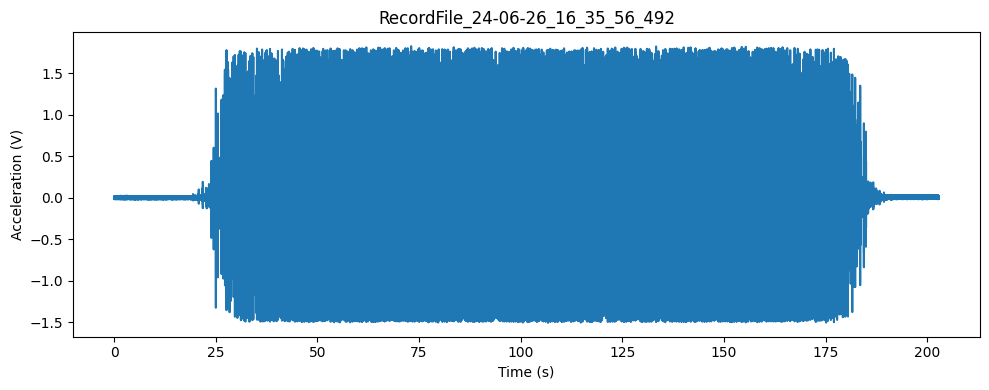

In [ ]:
fe = int(1/np.mean(np.diff(t)))
print(f"Sampling frequency = {fe} Hz")

plt.figure(figsize=(10,4))
if id_channel != 12:
    plt.plot(t, s)
else:
    sos = butter(4, 1, 'lowpass', fs=fe, output='sos')
    filtered = sosfilt(sos, s)
    plt.plot(t, s*160/6.6, alpha=0.25)
    plt.plot(t, filtered*160/6.6)
plt.xlabel('Time (s)')
if id_channel in [0,1,2,3]:
    plt.ylabel('Sound (V)')
elif id_channel in [4,5,6,7,8,9,10]:
    plt.ylabel('Acceleration (V)')
elif id_channel == 12:
    plt.ylabel('Speed (km/s)')
plt.title(name)
plt.tight_layout()
plt.show()

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

NameError: name 'welch' is not defined

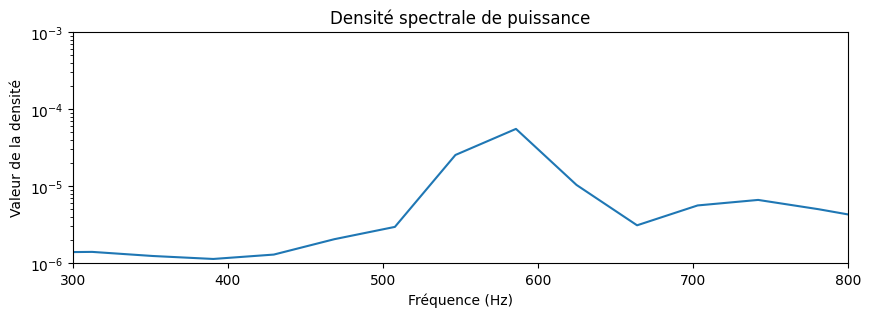

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlim(300, 800)
plt.ylim(1e-6, 1e-3)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

In [ ]:
from scipy.signal import filtfilt

# Définir un filtre passe-bande
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs  # Fréquence de Nyquist
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band', analog=False)
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return filtfilt(b, a, data)

In [ ]:
# Paramètres du filtre passe-bande
lowcut = 25   # Fréquence basse (Hz)
highcut = 125  # Fréquence haute (Hz)
fe = 10000      # Fréquence d'échantillonnage (Hz)

# Application du filtre
s -= np.mean(s)  # Recentrage du signal
filtered_signal = bandpass_filter(s, lowcut, highcut, fs=fe)

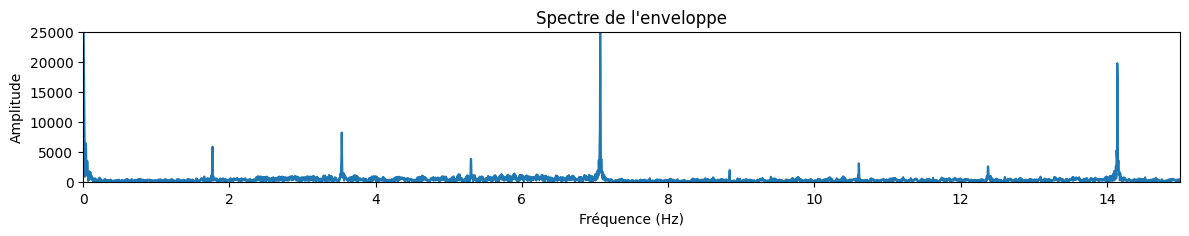

In [ ]:
from scipy.signal import hilbert

analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 15)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

In [ ]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(np.abs(fft_envelope[:len(freqs)//2]), height=5000)

peak_frequencies = freqs[peaks]

print("Fréquences des pics supérieurs à 5000 :", peak_frequencies)

Fréquences des pics supérieurs à 5000 : [3.45183652e-02 1.77029902e+00 3.53566684e+00 7.07133368e+00
 1.41328050e+01 1.41426674e+01 2.12189322e+01 2.82902659e+01
 3.53615996e+01 3.88972664e+01 4.24329333e+01 4.77388991e+01
 4.95042670e+01]


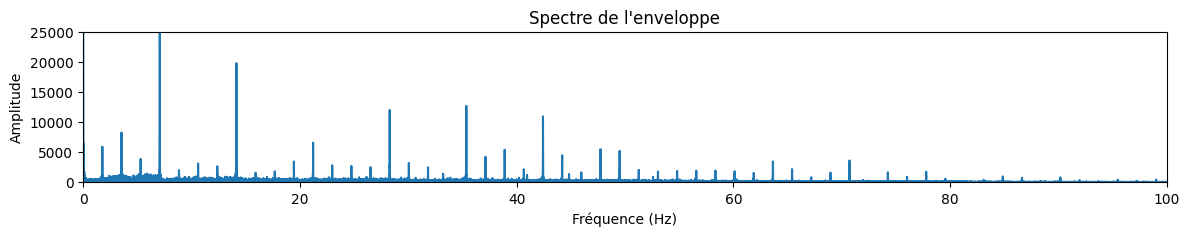

In [ ]:
from scipy.signal import hilbert

analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 100)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

In [ ]:
# Paramètres du filtre passe-bande
lowcut = 500   # Fréquence basse (Hz)
highcut = 650  # Fréquence haute (Hz)
fe = 10000      # Fréquence d'échantillonnage (Hz)

# Application du filtre
s -= np.mean(s)  # Recentrage du signal
filtered_signal = bandpass_filter(s, lowcut, highcut, fs=fe)

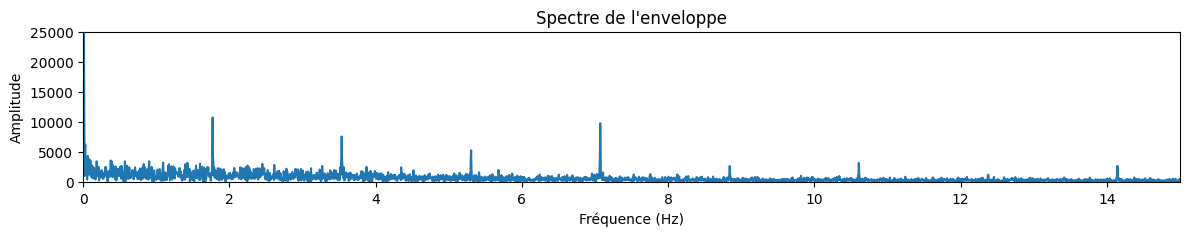

In [ ]:
from scipy.signal import hilbert

analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 15)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

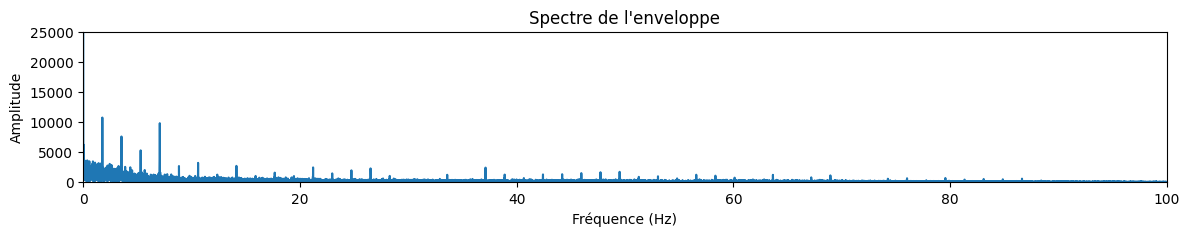

In [ ]:
from scipy.signal import hilbert

analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 100)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

# **Acc_2**

In [ ]:
id_channel = 5 # selection of the channel

signal_id = l_signal_id[id_channel]

signal = data.get(signal_id)
#signal = data.filter([signal_id])
N = signal.samples.size
t = signal.timestamps
s = signal.samples

In [ ]:
# Définir les indices de début et de fin pour chaque segment
segments = [
    (0, 2581109, 0),
    (2581110, 5162219, 1),
    (5162220, 7743329, 2),
    (7743330, 10324439, 3),
    (10324440, 12905549, 4),
    (12905550, 15486659, 5),
    (15486660, 18067769, 6),
    (18067770, 20279055, 7)
]

# Durée à ajouter pour chaque segment (en secondes)
time_increment = 25.811090000000004

# Correction de la liste t
t_corrected = t.copy()  # On part de la liste existante
for start, end, multiplier in segments:
    t_corrected[start:end + 1] = [x + multiplier * time_increment for x in t[start:end + 1]]

# La liste t_corrected contient maintenant les temps corrigés


In [ ]:
# Initialisation des variables
max_gap = 0
max_gap_indices = (None, None)  # Pour stocker les indices (i - 1, i) correspondant au plus grand écart

# Parcours de la liste pour calculer les écarts consécutifs
for i in range(1, len(t_corrected)):
    gap = t_corrected[i] - t_corrected[i - 1]  # Calcul de l'écart entre deux éléments consécutifs
    if gap > max_gap:  # Si l'écart est plus grand que l'écart maximum actuel
        max_gap = gap  # Mise à jour de l'écart maximum
        max_gap_indices = (i - 1, i)  # Mise à jour des indices correspondant à cet écart

# Affichage du résultat
print(f"L'écart maximum est : {max_gap}")
print(f"Indices correspondants : {max_gap_indices}")
print(f"Valeurs correspondantes : t_corrected[{max_gap_indices[0]}] = {t_corrected[max_gap_indices[0]]}, "
      f"t_corrected[{max_gap_indices[1]}] = {t_corrected[max_gap_indices[1]]}")


L'écart maximum est : 1.0000000031595846e-05
Indices correspondants : (12800049, 12800050)
Valeurs correspondantes : t_corrected[12800049] = 128.00045, t_corrected[12800050] = 128.00046000000003


In [ ]:
t = t_corrected[::10]
s = signal.samples[::10]
s -= np.mean(s)

Sampling frequency = 10000 Hz


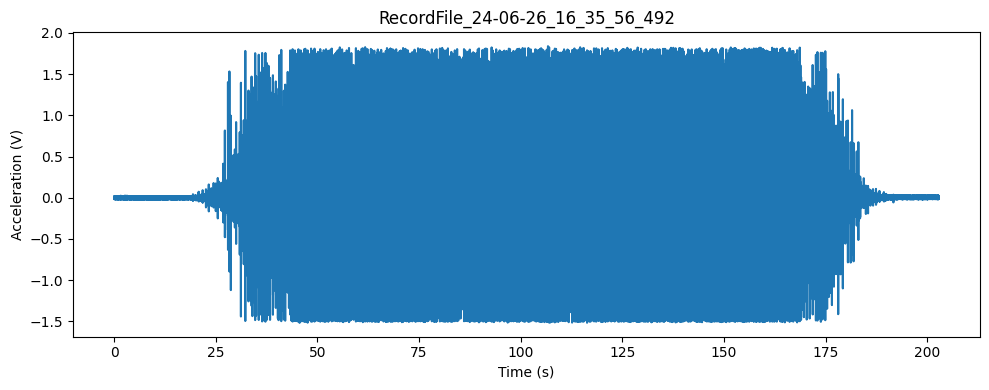

In [ ]:
fe = int(1/np.mean(np.diff(t)))
print(f"Sampling frequency = {fe} Hz")

plt.figure(figsize=(10,4))
if id_channel != 12:
    plt.plot(t, s)
else:
    sos = butter(4, 1, 'lowpass', fs=fe, output='sos')
    filtered = sosfilt(sos, s)
    plt.plot(t, s*160/6.6, alpha=0.25)
    plt.plot(t, filtered*160/6.6)
plt.xlabel('Time (s)')
if id_channel in [0,1,2,3]:
    plt.ylabel('Sound (V)')
elif id_channel in [4,5,6,7,8,9,10]:
    plt.ylabel('Acceleration (V)')
elif id_channel == 12:
    plt.ylabel('Speed (km/s)')
plt.title(name)
plt.tight_layout()
plt.show()

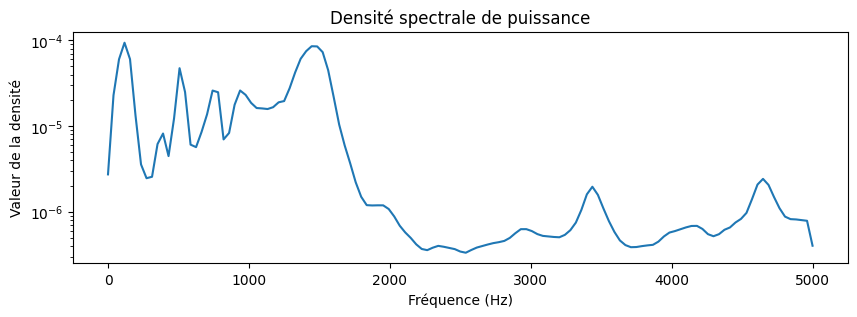

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

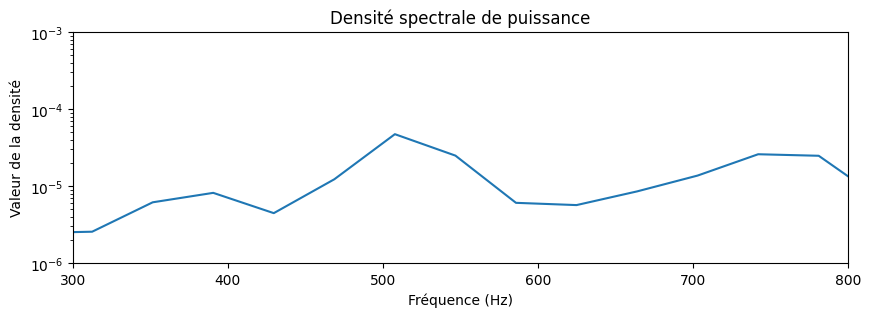

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlim(300, 800)
plt.ylim(1e-6, 1e-3)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

In [ ]:
# Paramètres du filtre passe-bande
lowcut = 25   # Fréquence basse (Hz)
highcut = 150  # Fréquence haute (Hz)
fe = 10000      # Fréquence d'échantillonnage (Hz)

# Application du filtre
s -= np.mean(s)  # Recentrage du signal
filtered_signal = bandpass_filter(s, lowcut, highcut, fs=fe)

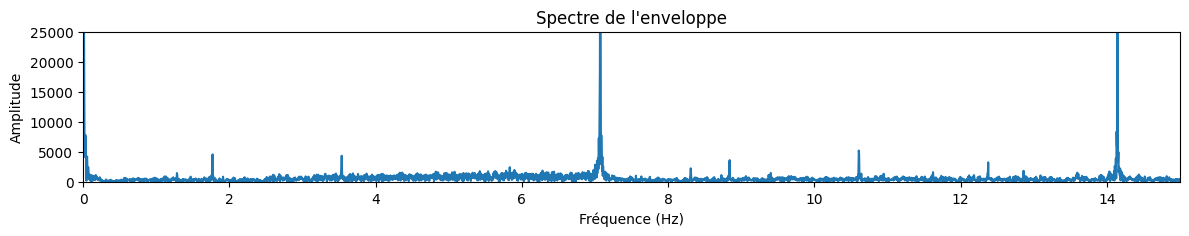

In [ ]:
from scipy.signal import hilbert

analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 15)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

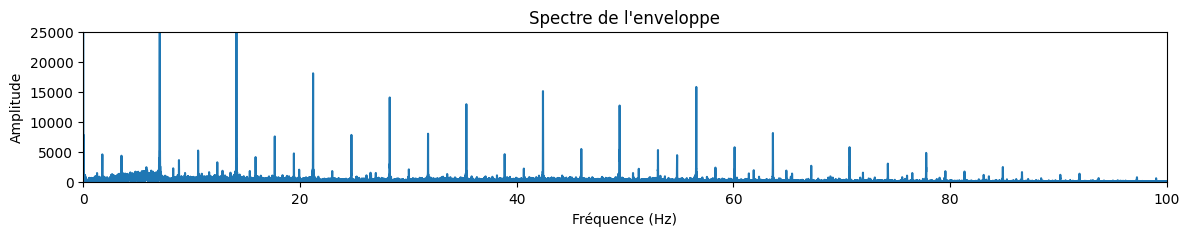

In [ ]:
from scipy.signal import hilbert

analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 100)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

In [ ]:
# Paramètres du filtre passe-bande
lowcut = 450   # Fréquence basse (Hz)
highcut = 550  # Fréquence haute (Hz)
fe = 10000      # Fréquence d'échantillonnage (Hz)

# Application du filtre
s -= np.mean(s)  # Recentrage du signal
filtered_signal = bandpass_filter(s, lowcut, highcut, fs=fe)

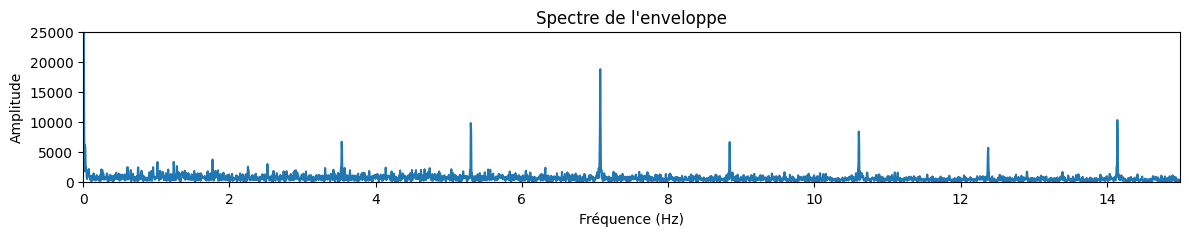

In [ ]:
from scipy.signal import hilbert

analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 15)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

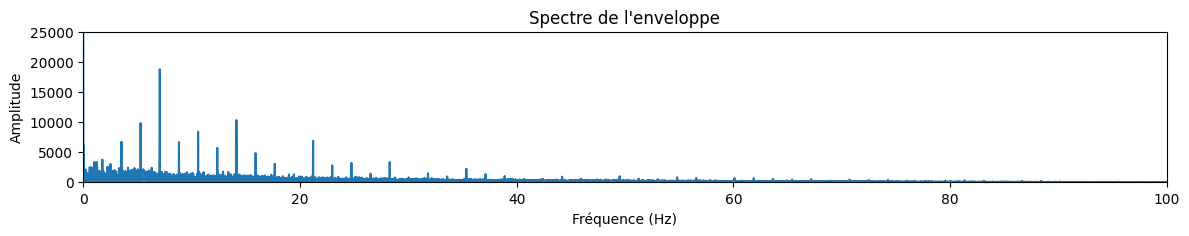

In [ ]:
from scipy.signal import hilbert

analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 100)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

# **Acc_3**

In [ ]:
id_channel = 6 # selection of the channel

signal_id = l_signal_id[id_channel]

signal = data.get(signal_id)
#signal = data.filter([signal_id])
N = signal.samples.size
t = signal.timestamps
s = signal.samples

In [ ]:
# Définir les indices de début et de fin pour chaque segment
segments = [
    (0, 2581109, 0),
    (2581110, 5162219, 1),
    (5162220, 7743329, 2),
    (7743330, 10324439, 3),
    (10324440, 12905549, 4),
    (12905550, 15486659, 5),
    (15486660, 18067769, 6),
    (18067770, 20279055, 7)
]

# Durée à ajouter pour chaque segment (en secondes)
time_increment = 25.811090000000004

# Correction de la liste t
t_corrected = t.copy()  # On part de la liste existante
for start, end, multiplier in segments:
    t_corrected[start:end + 1] = [x + multiplier * time_increment for x in t[start:end + 1]]

# La liste t_corrected contient maintenant les temps corrigés


In [ ]:
# Initialisation des variables
max_gap = 0
max_gap_indices = (None, None)  # Pour stocker les indices (i - 1, i) correspondant au plus grand écart

# Parcours de la liste pour calculer les écarts consécutifs
for i in range(1, len(t_corrected)):
    gap = t_corrected[i] - t_corrected[i - 1]  # Calcul de l'écart entre deux éléments consécutifs
    if gap > max_gap:  # Si l'écart est plus grand que l'écart maximum actuel
        max_gap = gap  # Mise à jour de l'écart maximum
        max_gap_indices = (i - 1, i)  # Mise à jour des indices correspondant à cet écart

# Affichage du résultat
print(f"L'écart maximum est : {max_gap}")
print(f"Indices correspondants : {max_gap_indices}")
print(f"Valeurs correspondantes : t_corrected[{max_gap_indices[0]}] = {t_corrected[max_gap_indices[0]]}, "
      f"t_corrected[{max_gap_indices[1]}] = {t_corrected[max_gap_indices[1]]}")


L'écart maximum est : 1.0000000031595846e-05
Indices correspondants : (12800049, 12800050)
Valeurs correspondantes : t_corrected[12800049] = 128.00045, t_corrected[12800050] = 128.00046000000003


In [ ]:
t = t_corrected[::10]
s = signal.samples[::10]
s -= np.mean(s)

Sampling frequency = 10000 Hz


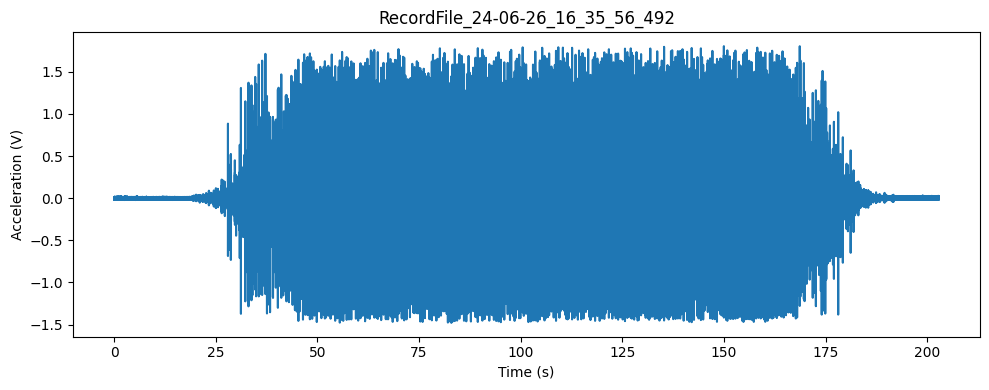

In [ ]:
fe = int(1/np.mean(np.diff(t)))
print(f"Sampling frequency = {fe} Hz")

plt.figure(figsize=(10,4))
if id_channel != 12:
    plt.plot(t, s)
else:
    sos = butter(4, 1, 'lowpass', fs=fe, output='sos')
    filtered = sosfilt(sos, s)
    plt.plot(t, s*160/6.6, alpha=0.25)
    plt.plot(t, filtered*160/6.6)
plt.xlabel('Time (s)')
if id_channel in [0,1,2,3]:
    plt.ylabel('Sound (V)')
elif id_channel in [4,5,6,7,8,9,10]:
    plt.ylabel('Acceleration (V)')
elif id_channel == 12:
    plt.ylabel('Speed (km/s)')
plt.title(name)
plt.tight_layout()
plt.show()

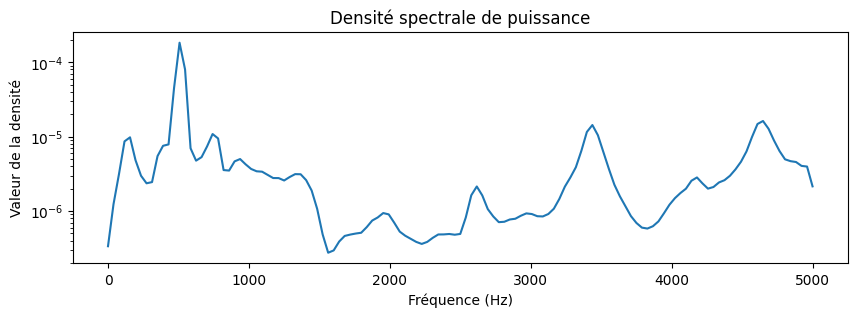

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

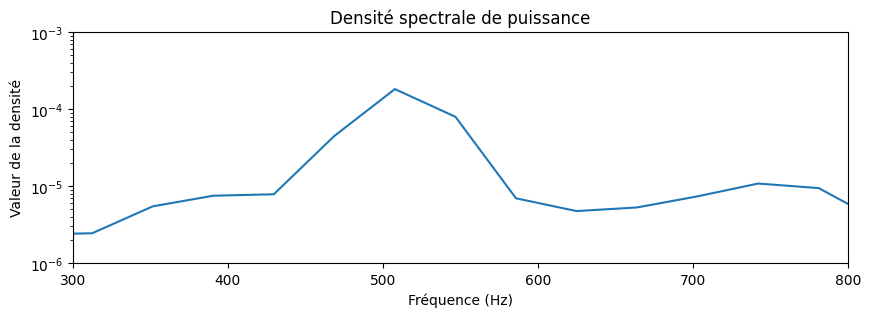

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlim(300, 800)
plt.ylim(1e-6, 1e-3)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

In [ ]:
# Paramètres du filtre passe-bande
lowcut = 450   # Fréquence basse (Hz)
highcut = 550  # Fréquence haute (Hz)
fe = 10000      # Fréquence d'échantillonnage (Hz)

# Application du filtre
s -= np.mean(s)  # Recentrage du signal
filtered_signal = bandpass_filter(s, lowcut, highcut, fs=fe)

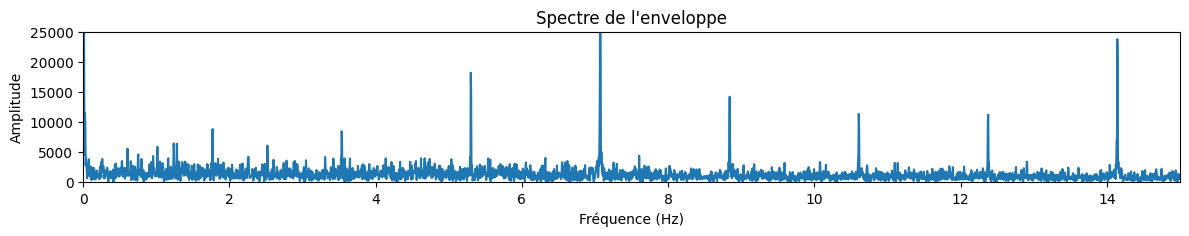

In [ ]:
from scipy.signal import hilbert

analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 15)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

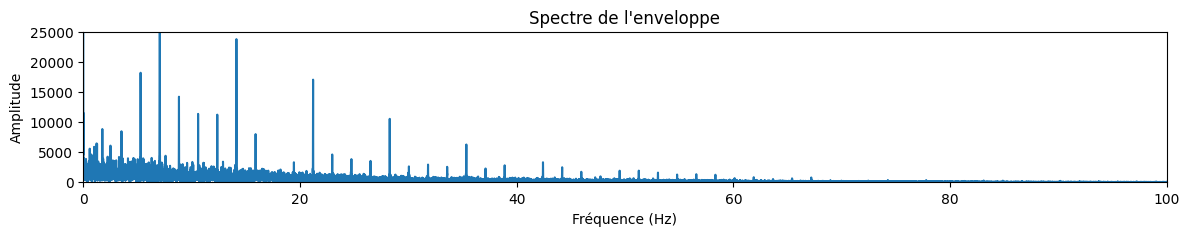

In [ ]:
from scipy.signal import hilbert

analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 100)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

# **Acc_4**

In [ ]:
id_channel = 7 # selection of the channel

signal_id = l_signal_id[id_channel]

signal = data.get(signal_id)
#signal = data.filter([signal_id])
N = signal.samples.size
t = signal.timestamps
s = signal.samples

In [ ]:
# Définir les indices de début et de fin pour chaque segment
segments = [
    (0, 2581109, 0),
    (2581110, 5162219, 1),
    (5162220, 7743329, 2),
    (7743330, 10324439, 3),
    (10324440, 12905549, 4),
    (12905550, 15486659, 5),
    (15486660, 18067769, 6),
    (18067770, 20279055, 7)
]

# Durée à ajouter pour chaque segment (en secondes)
time_increment = 25.811090000000004

# Correction de la liste t
t_corrected = t.copy()  # On part de la liste existante
for start, end, multiplier in segments:
    t_corrected[start:end + 1] = [x + multiplier * time_increment for x in t[start:end + 1]]

# La liste t_corrected contient maintenant les temps corrigés

In [ ]:
# Initialisation des variables
max_gap = 0
max_gap_indices = (None, None)  # Pour stocker les indices (i - 1, i) correspondant au plus grand écart

# Parcours de la liste pour calculer les écarts consécutifs
for i in range(1, len(t_corrected)):
    gap = t_corrected[i] - t_corrected[i - 1]  # Calcul de l'écart entre deux éléments consécutifs
    if gap > max_gap:  # Si l'écart est plus grand que l'écart maximum actuel
        max_gap = gap  # Mise à jour de l'écart maximum
        max_gap_indices = (i - 1, i)  # Mise à jour des indices correspondant à cet écart

# Affichage du résultat
print(f"L'écart maximum est : {max_gap}")
print(f"Indices correspondants : {max_gap_indices}")
print(f"Valeurs correspondantes : t_corrected[{max_gap_indices[0]}] = {t_corrected[max_gap_indices[0]]}, "
      f"t_corrected[{max_gap_indices[1]}] = {t_corrected[max_gap_indices[1]]}")


L'écart maximum est : 1.0000000031595846e-05
Indices correspondants : (12800049, 12800050)
Valeurs correspondantes : t_corrected[12800049] = 128.00045, t_corrected[12800050] = 128.00046000000003


In [ ]:
t = t_corrected[::10]
s = signal.samples[::10]
s -= np.mean(s)

Sampling frequency = 10000 Hz


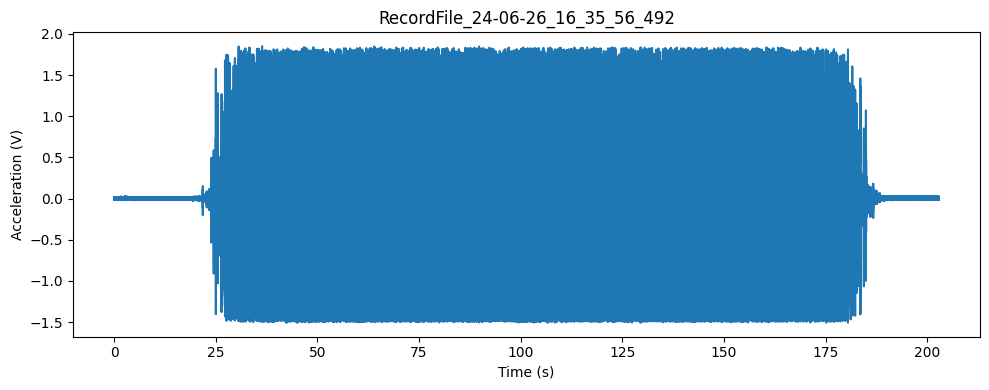

In [ ]:
fe = int(1/np.mean(np.diff(t)))
print(f"Sampling frequency = {fe} Hz")

plt.figure(figsize=(10,4))
if id_channel != 12:
    plt.plot(t, s)
else:
    sos = butter(4, 1, 'lowpass', fs=fe, output='sos')
    filtered = sosfilt(sos, s)
    plt.plot(t, s*160/6.6, alpha=0.25)
    plt.plot(t, filtered*160/6.6)
plt.xlabel('Time (s)')
if id_channel in [0,1,2,3]:
    plt.ylabel('Sound (V)')
elif id_channel in [4,5,6,7,8,9,10]:
    plt.ylabel('Acceleration (V)')
elif id_channel == 12:
    plt.ylabel('Speed (km/s)')
plt.title(name)
plt.tight_layout()
plt.show()

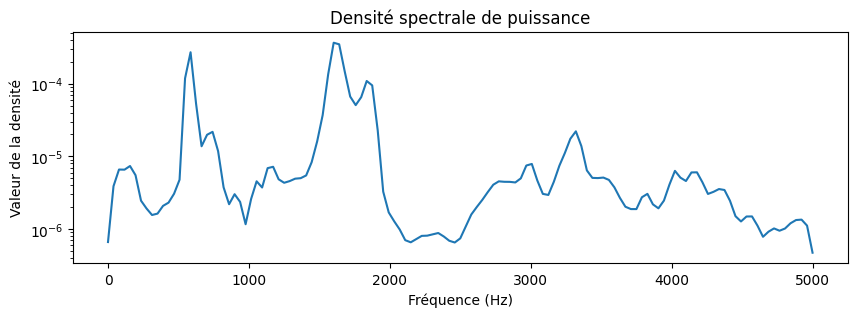

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

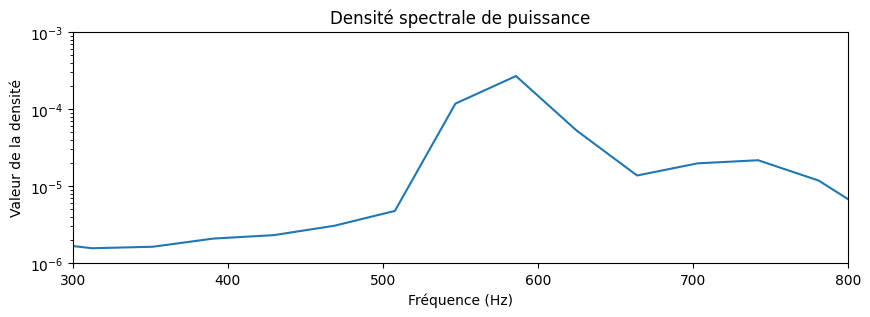

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlim(300, 800)
plt.ylim(1e-6, 1e-3)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

In [ ]:
# Paramètres du filtre passe-bande
lowcut = 500   # Fréquence basse (Hz)
highcut = 650  # Fréquence haute (Hz)
fe = 10000      # Fréquence d'échantillonnage (Hz)

# Application du filtre
s -= np.mean(s)  # Recentrage du signal
filtered_signal = bandpass_filter(s, lowcut, highcut, fs=fe)

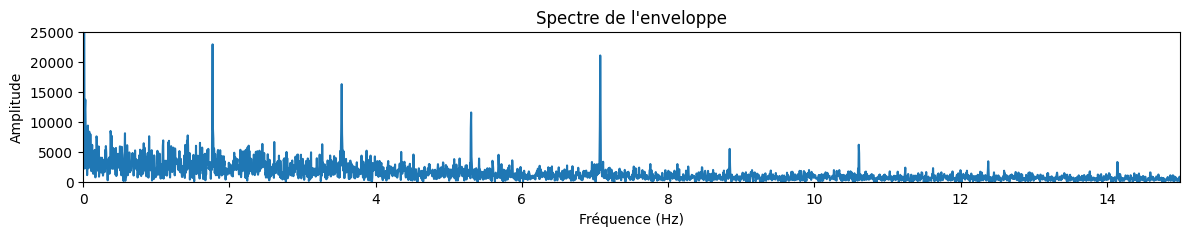

In [ ]:
analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 15)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

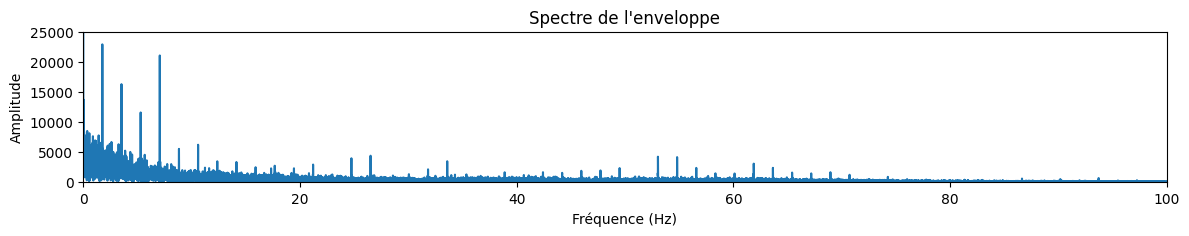

In [ ]:
analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 100)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

# **Son_1**

In [ ]:
id_channel = 0 # selection of the channel

signal_id = l_signal_id[id_channel]

signal = data.get(signal_id)
#signal = data.filter([signal_id])
N = signal.samples.size
t = signal.timestamps
s = signal.samples

In [ ]:
# Définir les indices de début et de fin pour chaque segment
segments = [
    (0, 2581109, 0),
    (2581110, 5162219, 1),
    (5162220, 7743329, 2),
    (7743330, 10324439, 3),
    (10324440, 12905549, 4),
    (12905550, 15486659, 5),
    (15486660, 18067769, 6),
    (18067770, 20279055, 7)
]

# Durée à ajouter pour chaque segment (en secondes)
time_increment = 25.811090000000004

# Correction de la liste t
t_corrected = t.copy()  # On part de la liste existante
for start, end, multiplier in segments:
    t_corrected[start:end + 1] = [x + multiplier * time_increment for x in t[start:end + 1]]

# La liste t_corrected contient maintenant les temps corrigés

In [ ]:
# Initialisation des variables
max_gap = 0
max_gap_indices = (None, None)  # Pour stocker les indices (i - 1, i) correspondant au plus grand écart

# Parcours de la liste pour calculer les écarts consécutifs
for i in range(1, len(t_corrected)):
    gap = t_corrected[i] - t_corrected[i - 1]  # Calcul de l'écart entre deux éléments consécutifs
    if gap > max_gap:  # Si l'écart est plus grand que l'écart maximum actuel
        max_gap = gap  # Mise à jour de l'écart maximum
        max_gap_indices = (i - 1, i)  # Mise à jour des indices correspondant à cet écart

# Affichage du résultat
print(f"L'écart maximum est : {max_gap}")
print(f"Indices correspondants : {max_gap_indices}")
print(f"Valeurs correspondantes : t_corrected[{max_gap_indices[0]}] = {t_corrected[max_gap_indices[0]]}, "
      f"t_corrected[{max_gap_indices[1]}] = {t_corrected[max_gap_indices[1]]}")


L'écart maximum est : 1.0000000031595846e-05
Indices correspondants : (12800049, 12800050)
Valeurs correspondantes : t_corrected[12800049] = 128.00045, t_corrected[12800050] = 128.00046000000003


In [ ]:
t = t_corrected[::10]
s = signal.samples[::10]
#s -= np.mean(s)

In [ ]:
fe = int(1/np.mean(np.diff(t)))
#fe = 10000
from scipy.io.wavfile import write
import IPython.display as ipd  # Pour écouter directement dans Jupyter Notebook (optionnel)

# Normalisation du signal
s_normalized = s / np.max(np.abs(s))  # Normalisation entre -1 et 1

# Sauvegarde dans un fichier WAV
output_filename = "Son_1_output.wav"
write(output_filename, rate=fe, data=(s_normalized * 32767).astype(np.int16))  # Conversion en int16

print(f"Fichier audio enregistré sous le nom : {output_filename}")

# Optionnel : Lecture directe dans Jupyter Notebook ou IPython
ipd.Audio(output_filename)  # Lecture dans le notebook


Fichier audio enregistré sous le nom : Son_1_output.wav


Sampling frequency = 10000 Hz


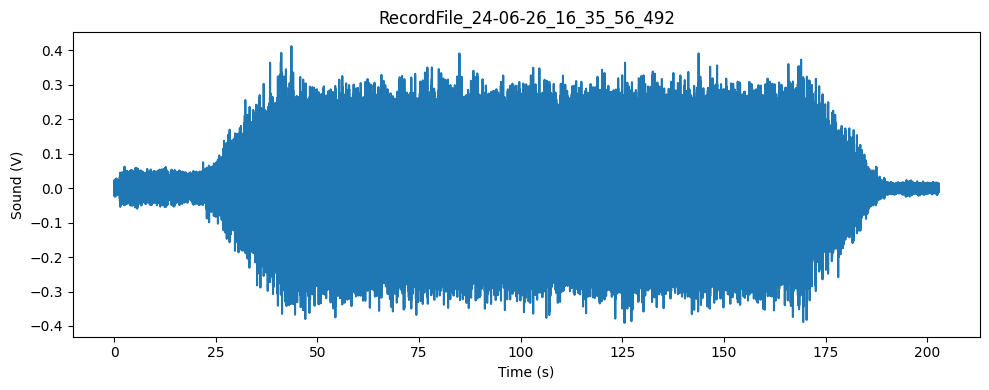

In [ ]:
fe = int(1/np.mean(np.diff(t)))
print(f"Sampling frequency = {fe} Hz")

plt.figure(figsize=(10,4))
if id_channel != 12:
    plt.plot(t, s)
else:
    sos = butter(4, 1, 'lowpass', fs=fe, output='sos')
    filtered = sosfilt(sos, s)
    plt.plot(t, s*160/6.6, alpha=0.25)
    plt.plot(t, filtered*160/6.6)
plt.xlabel('Time (s)')
if id_channel in [0,1,2,3]:
    plt.ylabel('Sound (V)')
elif id_channel in [4,5,6,7,8,9,10]:
    plt.ylabel('Acceleration (V)')
elif id_channel == 12:
    plt.ylabel('Speed (km/s)')
plt.title(name)
plt.tight_layout()
plt.show()

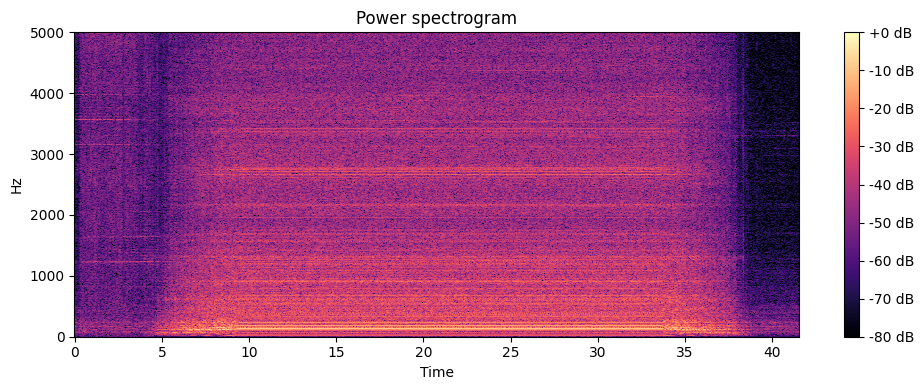

In [ ]:
D = np.abs(librosa.stft(s, n_fft=fe, hop_length=2500))
dim, N = D.shape

fig, ax = plt.subplots(figsize=(10,4))
img = librosa.display.specshow(librosa.amplitude_to_db(np.abs(D), ref=np.max),
                               y_axis='linear', # log, linear
                               x_axis='time',
                               ax=ax,
                               sr=fe)
ax.set_title('Power spectrogram')
fig.colorbar(img, ax=ax, format="%+2.0f dB")
fig.tight_layout()
fig.show()

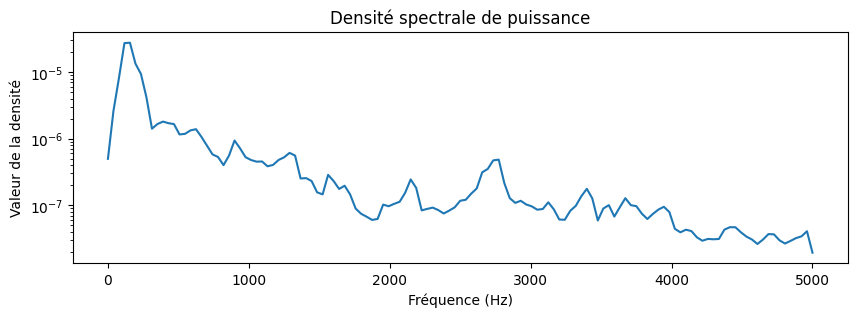

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

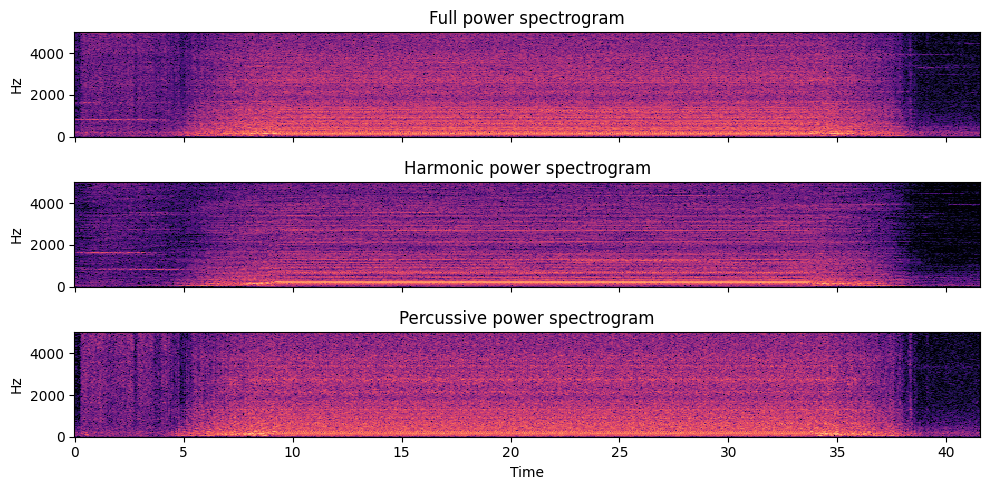

In [ ]:
H, P = librosa.decompose.hpss(D)

fig, ax = plt.subplots(figsize=(10,5), nrows=3, sharex=True, sharey=True)
img = librosa.display.specshow(librosa.amplitude_to_db(np.abs(D),
                                                       ref=np.max),
                         y_axis='linear', x_axis='time', ax=ax[0], sr=fe)
ax[0].set(title='Full power spectrogram')
ax[0].label_outer()
librosa.display.specshow(librosa.amplitude_to_db(np.abs(H),
                                                 ref=np.max(np.abs(D))),
                         y_axis='linear', x_axis='time', ax=ax[1], sr=fe)
ax[1].set(title='Harmonic power spectrogram')
ax[1].label_outer()
librosa.display.specshow(librosa.amplitude_to_db(np.abs(P),
                                                 ref=np.max(np.abs(D))),
                         y_axis='linear', x_axis='time', ax=ax[2], sr=fe)
ax[2].set(title='Percussive power spectrogram')
#fig.colorbar(img, ax=ax, format='%+2.0f dB')
fig.tight_layout()
fig.show()